<h2>Data Analytics- notebook, Motorcycle Sales</h2>

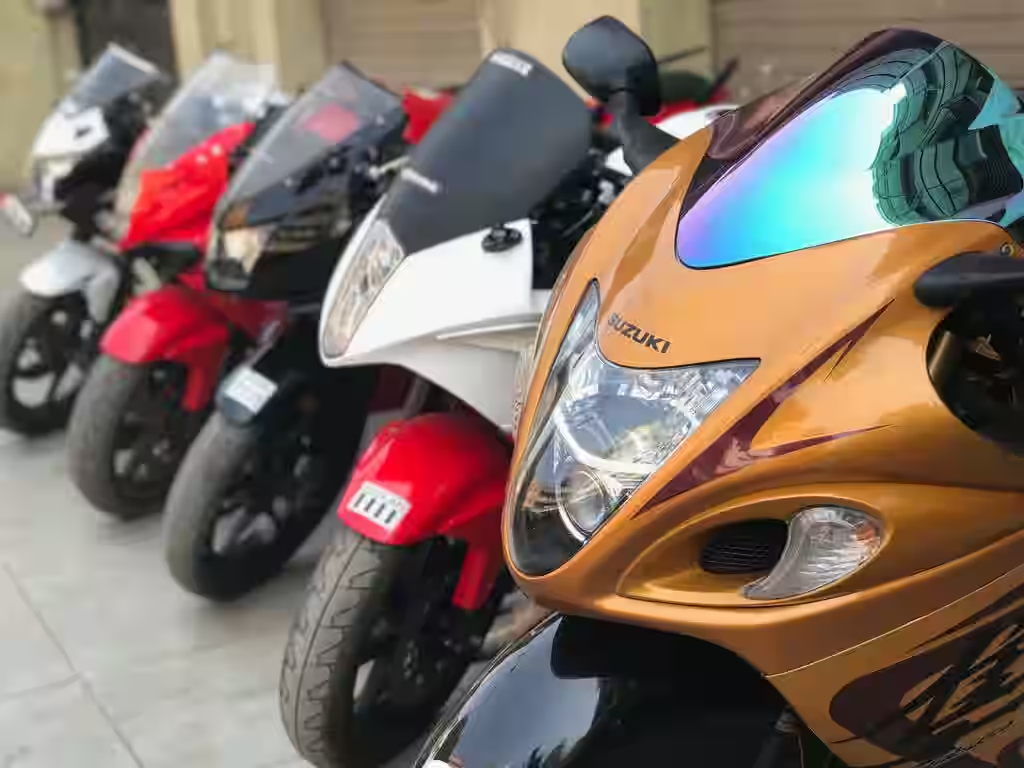

<h4><b>Dataset name:</b></h4>

Motorcycle sales.


<h4><b>Data source (url):</b></h4>

https://moodle.eoppimispalvelut.fi/course/view.php?id=21820

<h4><b>Data format:</b></h4>

Single csv-file

<h4><b>Data description, features and limitations:</b></h4>

Data Description:
The dataset has 1,061 rows and 7 columns, containing motorcycle listings. It's likely used for analyzing or predicting resale values.

Key Features:

* name: Model of the bike (279 unique entries)
* selling_price: Resale price, ranging from 5,000 to 760,000
* year: Year the bike was made, ranging from 1988 to 2020
* seller_type: Either Individual or Dealer (mostly Individual)
* owner: Ownership history (1st owner, 2nd owner, etc.)
* km_driven: Distance driven, from 350 to 880,000 km
* ex_showroom_price: Original price when new (41% of the values are missing)

Limitations:

* A large portion of ex_showroom_price values are missing
* Imbalance in data: very few dealer listings and mostly 1st owners
* Presence of outliers in km_driven and price
* No information on location, bike condition, or extra features

<h3><b>Code: importing modules, custom functions and loading the data</b></h3>

In [ ]:
# importing the usual data analytics modules
import numpy as np
import pandas as pd
import seaborn as sns

# Loading the data
motorcycles = pd.read_csv('motorcycle_sales.csv')
motorcycles

---

<h3><b>Code: Data clean-up procedure</b></h3>

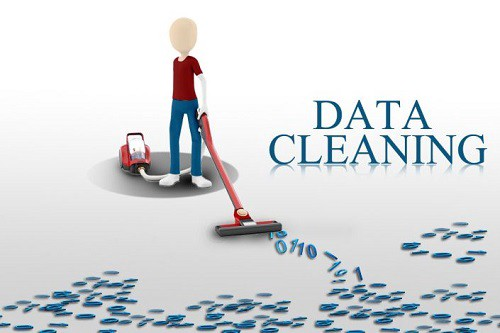

In [ ]:
# checking the nan values in the dataset
motorcycles.isna().sum() 

In [ ]:
# dropping the column because of the nan value percentage is high
motorcycle = motorcycles.drop('ex_showroom_price', axis=1)
motorcycle

<h2><b style="color: red;">Co-operate with another student: Jeremy</b></h2>

In [ ]:
# created a custom function to separate the ownership in numeric form!
# Jeremy helped in fixing the bug for the function.

def ownership_to_numeric(row):
    if row == '1st owner':
        return 1
    elif row == '2nd owner':
        return 2
    elif row == '3rd owner':
        return 3
    else:
        return 4

motorcycle['owner'] = motorcycle['owner'].apply(ownership_to_numeric)
motorcycle['owner'] = motorcycle['owner'].astype(int)

In [ ]:
# created a custom function for splitting the model of the bike and brand name 
def brand_model_splitter(row):
    row = row.split(" ")
    brand = row[0]
    return brand
    
motorcycle['brand'] = motorcycle['name'].apply(brand_model_splitter)
motorcycle

In [ ]:
# Group by 'brand' and count entries
brand_counts = motorcycle.groupby('brand').size()

# sorting the counts in descending order
sorted_brands = brand_counts.sort_values(ascending=False)

# taking top 5 brands
top_5_brands = sorted_brands.head(5).reset_index()  # reset_index makes 'brand' a column again
top_5_brands = top_5_brands['brand']

# printing result
top_motorcycle = motorcycle[motorcycle['brand'].isin(top_5_brands)].reset_index()
top_motorcycle['brand'].value_counts()


In [ ]:
# dropping the duplicates from the dataset

duplicates = motorcycle[motorcycle.duplicated()]
duplicates_all = motorcycle[motorcycle.duplicated(keep=False)]

df_cleaned = motorcycle.drop_duplicates()

<h2 style='color:red'><b>Note:</b></h2>
<p><b style="color: orange;">The distribution is leaning towards the older year so the distribution is not normal so you need to keep in mind.</b></p>

---

<h3><b>Code: Data analysis</b></h3>

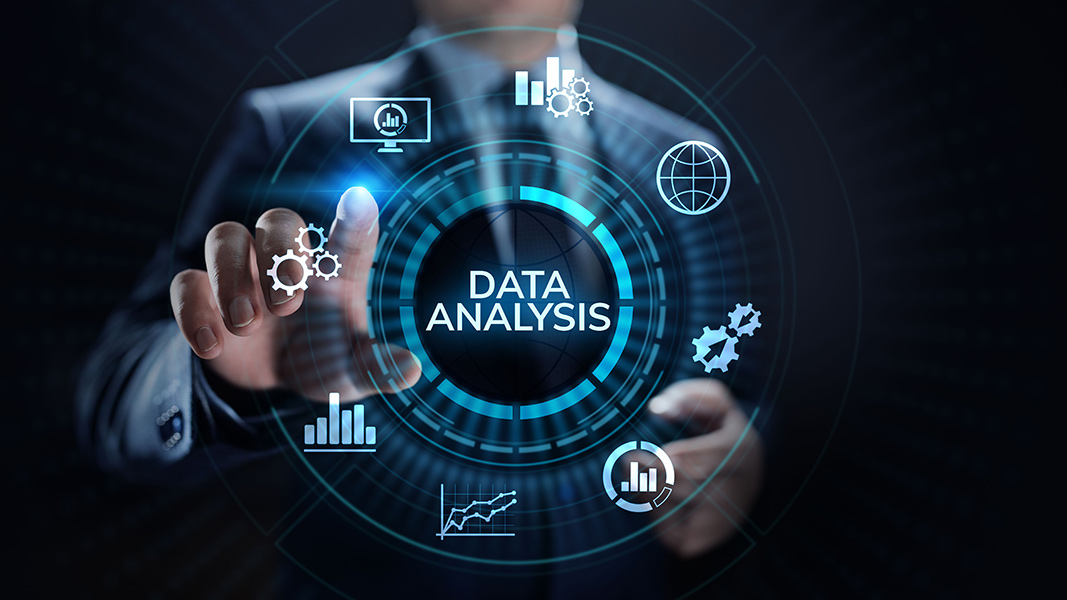


In [ ]:
# Pairplot with the hue as Brand

sns.pairplot(top_motorcycle, hue='brand')

* <b style="color: orange;"> Honda is one of the most popular brand among past year's

* Honda is best to buy among the other brands

In [ ]:
# Correlation matrix

correlations = motorcycle.select_dtypes(include="number")
correlations_matrix = correlations.corr()

# plot correlation matrix
sns.heatmap(correlations_matrix, annot=True, cmap='icefire')


<b style="color: orange;"><h3>Results:</h3>

<li> Newer motorcycles usually sell for more money (correlation is 0.69).</li>
<li> The year the motorcycle was made is the most important     thing for price. Newer motorcycles cost more.</li>
<li> Motorcycles with more kilometers driven usually sell for less (correlation is -0.36).</li>
<li> The number of owners doesn’t really change the price much (correlation is -0.11).</li>
</b>

In [ ]:
# Regression plot, hue as brand
sns.lmplot(y='selling_price', x='year', data=top_motorcycle, hue='brand')

<b style="color: orange;"><li>Royal Enfield is more popular than other motorcycle brands. It's kind of like the Mercedes of bikes.</li></b>

In [ ]:
# Regression plot, hue as brand 

sns.lmplot(x='owner', y='year', data=top_motorcycle, hue='brand')

In [ ]:
# pair plot, hue on year

sns.pairplot(motorcycle , hue="year", palette='coolwarm')

In [ ]:
# Regression plot, hue as brand

top_motorcycle = top_motorcycle[top_motorcycle['km_driven'] < 200000]
sns.lmplot(data=top_motorcycle, x='km_driven', y="selling_price", hue='brand')

* <b style="color: orange;"> Royal Enfield bikes usually start having problems after 60,000 km.

* That’s why people don’t want to buy one that has been driven more than that.

* Other motorcycle brands last longer.
</b>


In [ ]:
# pair plot, hue on selling price.
# filtering outliers

motorcycle = motorcycle[motorcycle['selling_price'] < 50000]
sns.pairplot(motorcycle , hue="selling_price", palette="magma")

In [ ]:
# Scatterplot plot, hue on selling price.
# filtering outliers

motorcycle = motorcycle[motorcycle['km_driven'] < 120000]
sns.scatterplot(data=motorcycle, x="km_driven", y="year", hue="selling_price", palette="magma")

* <b style="color: orange;">Higher the year, less driven motorcycle, more the selling price</b>

In [ ]:
# Regression plot, hue as owner

sns.lmplot(x='year', y='selling_price', data=motorcycle, hue='owner')

<b style="color: orange;"><li>So, the number of owners doesn’t really affect the selling price, no matter what year the motorcycle is.</li></b>

---

<h3><b>Results and summary:</b></h3>

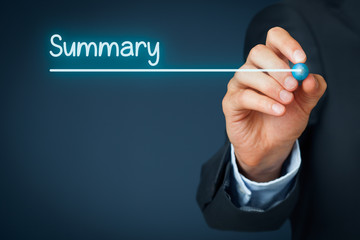

### <span style="color:orange;">Results</span>

- <span style="color:orange;">The selling price is mostly influenced by the year of manufacture and kilometers driven.</span>  
- <span style="color:orange;">Newer motorcycles tend to have a higher selling price.</span>  
- <span style="color:orange;">Motorcycles that have been driven more usually have a lower price — this shows a negative correlation.</span>  
- <span style="color:orange;">The number of previous owners does not significantly affect the selling price, regardless of the year.</span>  

### <span style="color:orange;">Brand Insight: Royal Enfield</span>

- <span style="color:orange;">Royal Enfield is more popular compared to other brands. It's often seen as the "Mercedes" of motorcycles.</span>  
- <span style="color:orange;">However, Royal Enfield bikes tend to start having mechanical issues after 60,000 km.</span>  
- <span style="color:orange;">Because of this, people usually avoid buying a Royal Enfield that has been driven more than 60,000 km.</span>  
- <span style="color:orange;">Other brands are generally more durable and remain reliable even after higher mileage.</span>  

### <span style="color:orange;">Summary</span>

- <span style="color:orange;">Higher manufacturing year + fewer kilometers driven = higher selling price</span>

---


<h3><b>Ideas for further improvements:</b></h3>

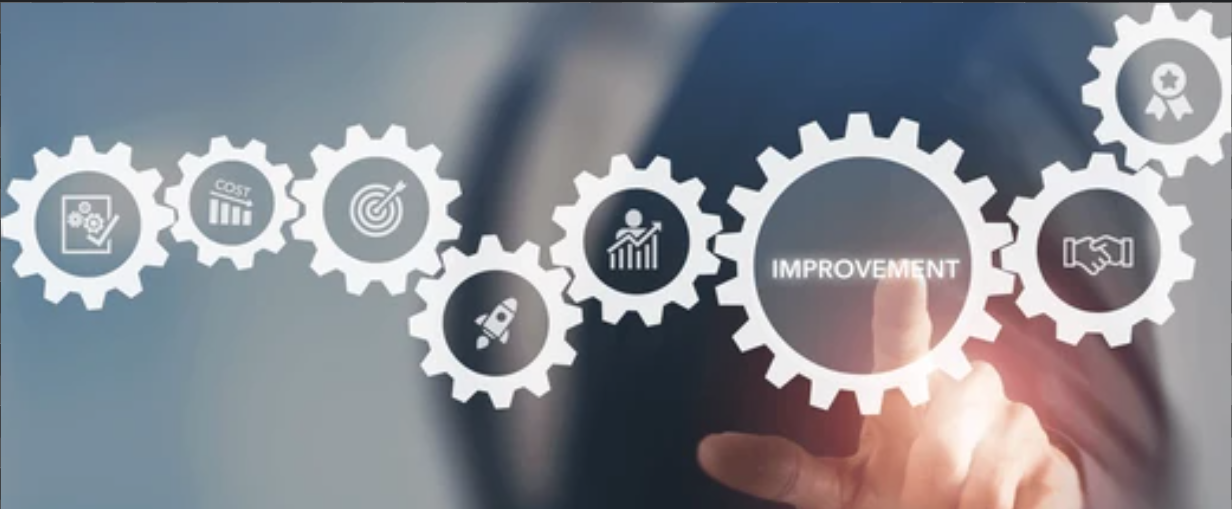

<h3><b style="color: orange;">This dataset can be improved by adding a few additional enhancement columns to include the following information:

* Category

* Color

* Mileage during the sale for each owner

* Tank Capacity

</b>

---

<h3><b>AI(Chatgpt) Used for:</b></h3>
<b style="color: orange;"><li> Facts checking </li></b> 

--- 